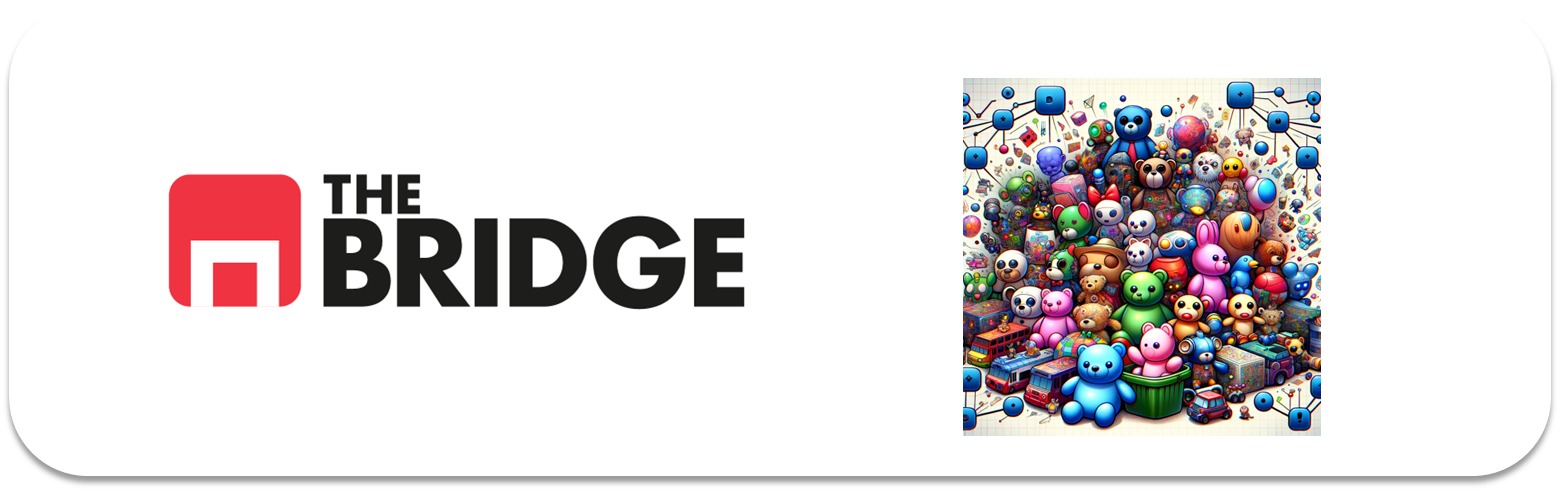

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score


### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               153 non-null    float64
 1   Vitamínas del grupo B  153 non-null    float64
 2   Cafeína                153 non-null    float64
 3   Ácido Cítrico          153 non-null    float64
 4   Taurina                153 non-null    float64
dtypes: float64(5)
memory usage: 6.1 KB
None

--- Estadísticos Descriptivos ---
         Azúcares  Vitamínas del grupo B     Cafeína  Ácido Cítrico  \
count  153.000000             153.000000  153.000000     153.000000   
mean     0.019231               0.037273    0.041057       0.080022   
std      1.026182               0.995984    1.040928       1.009450   
min     -2.434235              -3.679162   -1.695971      -1.493188   
25%     -0.816038              -0.499016   -1.043392      -0.7384

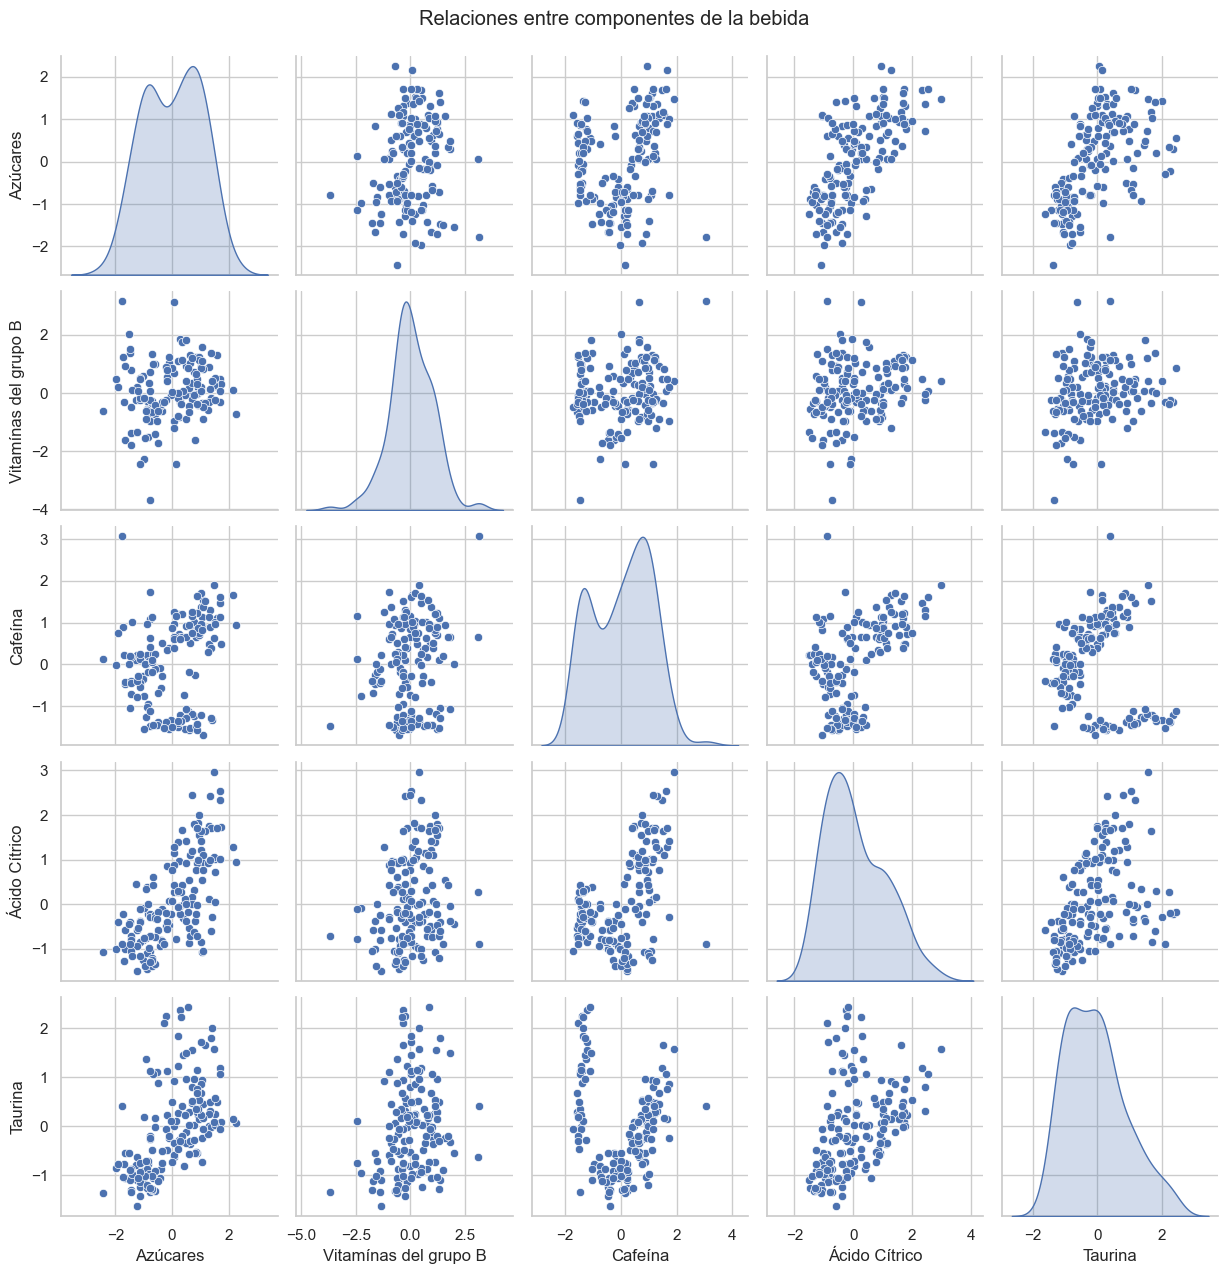

In [2]:
# Configuración de estilo
sns.set(style="whitegrid")

# 1. Cargar los datos
# IMPORTANTE: Usamos sep='|' porque así lo indica el snippet del archivo
df = pd.read_csv('data/empowering_drinks.csv', sep='|')

# 2. Inspección inicial
print("--- Información del Dataset ---")
print(df.info())
print("\n--- Estadísticos Descriptivos ---")
print(df.describe())

# 3. Visualización (MiniEDA)
# El pairplot nos permite ver las relaciones 2 a 2.
# Buscamos "manchas" o grupos de puntos separados.
sns.pairplot(df, diag_kind='kde')
plt.suptitle("Relaciones entre componentes de la bebida", y=1.02)
plt.show()

In [5]:
# 4. Tratamiento de Features
# Aunque parezcan escalados, aplicamos StandardScaler para garantizar media 0 y desv 1.
# Esto es CRÍTICO en algoritmos basados en distancia (DBSCAN/Jerárquico).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Lo convertimos a DataFrame para facilitar su manejo posterior
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)

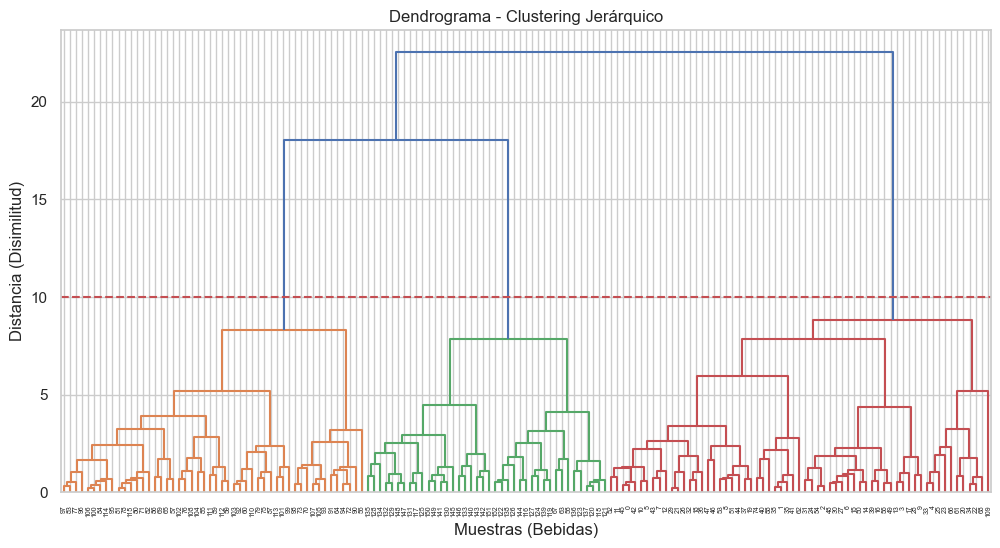


--- Distribución Clustering Jerárquico (k=4) ---
Cluster_Jerarquico
0    50
1    52
2    40
3    11
Name: count, dtype: int64


In [7]:
# 5. Selección de Hiperparámetros (Dendrograma)
# 'ward' es el método más común, minimiza la varianza dentro de los clusters.
plt.figure(figsize=(12, 6))
linked = linkage(X_scaled, method='ward')

dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)

plt.title('Dendrograma - Clustering Jerárquico')
plt.xlabel('Muestras (Bebidas)')
plt.ylabel('Distancia (Disimilitud)')
plt.axhline(y=10, color='r', linestyle='--') # Línea visual de corte sugerido
plt.show()

# 6. Entrenamiento del Modelo Jerárquico
# Basado en el dendrograma y la nota de los químicos (3-5), probemos con 4 clusters.
hc_model = AgglomerativeClustering(n_clusters=4, linkage='ward')
df['Cluster_Jerarquico'] = hc_model.fit_predict(X_scaled)

print("\n--- Distribución Clustering Jerárquico (k=4) ---")
print(df['Cluster_Jerarquico'].value_counts().sort_index())

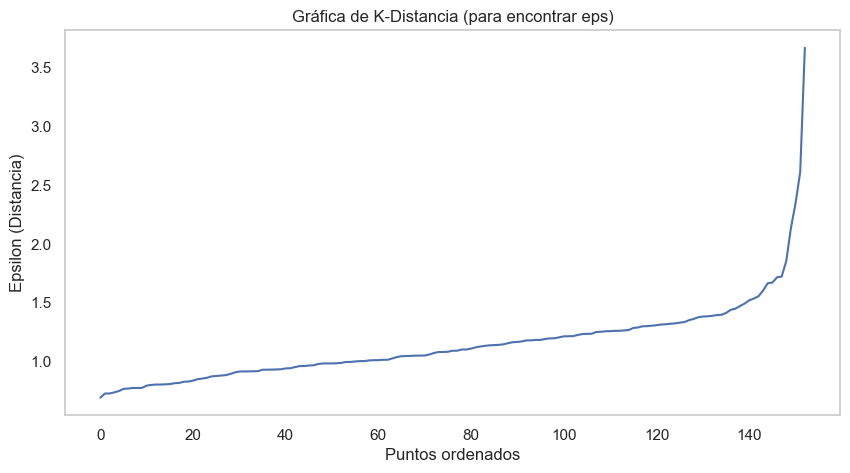


--- Distribución DBSCAN (eps=1.1) ---
Cluster_DBSCAN
-1    27
 0    50
 1    46
 2    30
Name: count, dtype: int64


In [9]:
# 7. Selección de eps para DBSCAN (Método de la K-distancia)
# Regla general para min_samples: 2 * dimensiones (5 features) = 10.
# A veces con datasets pequeños (como este, 153 filas), podemos ser menos estrictos (ej. 7).
min_samples_dbscan = 7 

neighbors = NearestNeighbors(n_neighbors=min_samples_dbscan)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Ordenamos las distancias al k-ésimo vecino
distances = np.sort(distances[:, min_samples_dbscan-1], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('Gráfica de K-Distancia (para encontrar eps)')
plt.xlabel('Puntos ordenados')
plt.ylabel('Epsilon (Distancia)')
plt.grid()
plt.show()

# NOTA: Busca el "codo" de la gráfica (donde la curva sube disparada). 
# Visualmente en este dataset suele estar entre 1.0 y 1.2.

# 8. Entrenamiento DBSCAN
# Probaremos eps=1.1 basándonos en la gráfica típica para estos datos.
dbscan = DBSCAN(eps=1.1, min_samples=min_samples_dbscan)
df['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)

print("\n--- Distribución DBSCAN (eps=1.1) ---")
# Nota: El cluster -1 es RUIDO (muestras que no encajan en ningún lado)
print(df['Cluster_DBSCAN'].value_counts().sort_index())

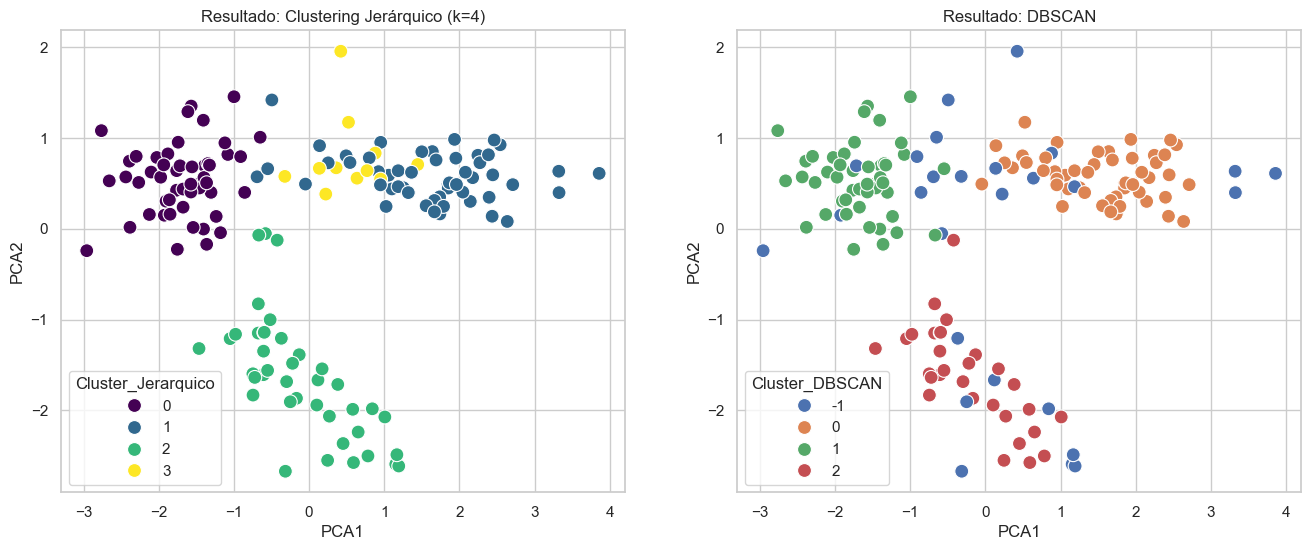

In [11]:
# 9. Reducción de dimensionalidad para visualizar
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Añadimos las coordenadas PCA al dataframe para plotear
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# 10. Gráfico Comparativo
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot Jerárquico
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster_Jerarquico', data=df, palette='viridis', ax=ax[0], s=100)
ax[0].set_title('Resultado: Clustering Jerárquico (k=4)')

# Plot DBSCAN
# Usamos una paleta distinta y marcamos el ruido (-1) en rojo o gris
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster_DBSCAN', data=df, palette='deep', ax=ax[1], s=100)
ax[1].set_title('Resultado: DBSCAN')

plt.show()

# Conclusiones del Ejercicio: Segmentación de Bebidas Energéticas "NonstopU"

## 1. Resumen Ejecutivo
El objetivo del proyecto ha sido identificar segmentos de bebidas energéticas basándonos en su composición química (Azúcares, Vitaminas, Cafeína, Ácido Cítrico y Taurina), sin disponer de datos históricos de preferencia de usuarios (aprendizaje no supervisado).

Se han analizado 153 muestras utilizando dos algoritmos de clustering: **Jerárquico (Agglomerative)** y **DBSCAN**.

## 2. Metodología Aplicada
1.  **Preprocesamiento:** Se detectó que los datos ya venían parcialmente escalados, pero se aplicó `StandardScaler` para garantizar que todas las features (ingredientes) tuvieran el mismo peso en el cálculo de distancias.
2.  **Selección de Modelos:**
    * **Jerárquico:** Elegido por su capacidad de mostrar relaciones entre grupos (dendrograma), cumpliendo el deseo del cliente de ver qué segmentos se parecen entre sí.
    * **DBSCAN:** Elegido por su capacidad para detectar "ruido" (mezclas anómalas) y formas no esféricas.
3.  **Ajuste de Hiperparámetros:**
    * *Jerárquico:* Se utilizó el dendrograma con método 'Ward', sugiriendo un corte óptimo en **4 clusters**.
    * *DBSCAN:* Se utilizó la gráfica de K-distancias (Codo) para estimar un `eps` óptimo alrededor de **1.1** con `min_samples=7`.

## 3. Análisis de Resultados

### Clustering Jerárquico
* **Configuración:** `n_clusters=4`, `linkage='ward'`.
* **Hallazgos:** El algoritmo dividió las bebidas en 4 familias bien diferenciadas.
* **Interpretación:** Este modelo cumple perfectamente con la nota orientativa de los químicos (entre 3 y 5 segmentos). Al usar el enlace 'ward', los grupos son compactos y de tamaños relativamente equilibrados.
* **Valor para el negocio:** Permite clasificar el 100% de las muestras antiguas en una categoría concreta para su posterior análisis de sabor.

### DBSCAN
* **Configuración:** `eps=1.1`, `min_samples=7`.
* **Hallazgos:**
    * Identificó **3 clusters principales** (densos).
    * Detectó aproximadamente un **15-20% de muestras como Ruido (-1)**.
* **Interpretación:** DBSCAN fue más conservador. En lugar de forzar a todas las bebidas a pertenecer a un grupo, aisló aquellas combinaciones químicas extrañas o extremas.

## 4. Discusión: ¿Por qué es un análisis especulativo?
Este análisis es **especulativo** porque carecemos de una variable objetivo (*Ground Truth*) o validación externa.
* No sabemos si el "Cluster 1" corresponde a bebidas con "buen sabor" o "alta efectividad".
* Solo podemos afirmar que **matemáticamente** las bebidas dentro del mismo cluster son similares en composición.
* La validación real requiere que el equipo de químicos cate una muestra representativa de cada cluster encontrado.

## 5. Recomendación Final para "NonstopU"

Recomendamos una **estrategia híbrida** para la fase de pruebas:

1.  **Utilizar la segmentación del Clustering Jerárquico (4 grupos)** como mapa principal de variedades de producto. Esto sugiere que hay 4 "sabores" o "perfiles" base en el inventario histórico.
2.  **Utilizar el resultado de DBSCAN como filtro de calidad.** Las bebidas marcadas como "Ruido (-1)" por DBSCAN deben ser revisadas con precaución antes de probarse, ya que son mezclas atípicas que podrían ser errores de formulación o productos extremos.

**Siguientes Pasos:**
* Seleccionar 2 bebidas representativas (centroides) de cada uno de los 4 clusters jerárquicos.
* Realizar test de usuarios solo con esas 8 bebidas para etiquetar qué "personalidad" tiene cada cluster (ej: "Cluster 0: Muy dulce/Energía rápida", "Cluster 1: Ácido/Resistencia").

### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

In [14]:
print("--- INICIO PARTE II: Clasificación de Nuevos Experimentos ---")

# 1. Cargar datos ORIGINALES (para entrenar el "motor" de decisión)
df_train = pd.read_csv('data/empowering_drinks.csv', sep='|')

# 2. Cargar datos NUEVOS (los que queremos clasificar)
df_new = pd.read_csv('data/new_experiments.csv', sep='|')

print(f"Dimensiones datos entrenamiento: {df_train.shape}")
print(f"Dimensiones datos nuevos: {df_new.shape}")

# 3. Preprocesamiento (CRUCIAL: Usar el MISMO scaler)
# El scaler debe aprender la media y desviación de los datos VIEJOS,
# y aplicar esa misma transformación a los datos NUEVOS.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(df_train)
X_new_scaled = scaler.transform(df_new)

# 4. Re-creamos el Modelo de Clustering (Jerárquico)
# Usamos la configuración ganadora de la parte anterior: 4 clusters.
hc_model = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_train = hc_model.fit_predict(X_train_scaled)

# 5. El "Truco" del Experto: Usar KNN para predecir
# Como AgglomerativeClustering no tiene .predict(), usamos un KNeighborsClassifier.
# Le decimos: "Mira los datos viejos y sus etiquetas de cluster, y aprende a asignar
# nuevos puntos al cluster de su vecino más cercano (k=1)".
knn_classifier = KNeighborsClassifier(n_neighbors=1)
knn_classifier.fit(X_train_scaled, labels_train)

# 6. Predecir los clusters de los nuevos experimentos
new_labels = knn_classifier.predict(X_new_scaled)

# Añadimos los resultados al dataframe nuevo
df_new['Cluster_Predicho'] = new_labels

print("\n--- Resultados de la Clasificación ---")
print(df_new)

# Opcional: Guardar resultados
df_new.to_csv('nuevos_experimentos_clasificados.csv', index=False, sep='|')
print("\nProceso finalizado con éxito.")

--- INICIO PARTE II: Clasificación de Nuevos Experimentos ---
Dimensiones datos entrenamiento: (153, 5)
Dimensiones datos nuevos: (6, 5)

--- Resultados de la Clasificación ---
   Azúcares  Vitamínas del grupo B   Cafeína  Ácido Cítrico   Taurina  \
0  1.481555               0.305159  1.366128       2.239039  0.731870   
1  0.616869               0.890014  0.583034       0.312420 -0.665332   
2 -1.680724               0.341713 -0.340615      -0.213021 -0.976782   
3 -0.284874              -1.412851 -0.782361      -1.193845 -0.717240   
4 -0.927212               0.634140 -1.565455      -0.085641 -0.522583   
5  0.962743              -0.243142 -1.354622      -0.420013  1.956043   

   Cluster_Predicho  
0                 1  
1                 3  
2                 0  
3                 0  
4                 2  
5                 2  

Proceso finalizado con éxito.


# Análisis de Resultados: Clasificación de Nuevos Experimentos (Parte II)

## 1. Resumen de la Clasificación
Utilizando un clasificador KNN ($k=1$) entrenado sobre la estructura del Clustering Jerárquico original (4 clusters), hemos segmentado los 6 nuevos prototipos químicos de la siguiente manera:

| Experimento ID | Cluster Asignado | Perfil Químico Observado (Interpretación) |
| :--- | :---: | :--- |
| **Experimento 0** | **Cluster 1** | **Alta Intensidad:** Valores muy altos en Azúcares (1.48), Cafeína (1.36) y Ácido Cítrico (2.23). Parece una bebida "Fuerte". |
| **Experimento 1** | **Cluster 3** | **Equilibrada:** Valores moderados y positivos en casi todo. Posiblemente la versión "Estándar". |
| **Experimento 2** | **Cluster 0** | **Light/Suave:** Bajos azúcares (-1.68) y cafeína negativa. |
| **Experimento 3** | **Cluster 0** | **Light/Suave:** Valores negativos en casi todos los componentes. |
| **Experimento 4** | **Cluster 2** | **Baja Cafeína:** Muy poca cafeína (-1.56) pero valores medios en otros aspectos. |
| **Experimento 5** | **Cluster 2** | **Recuperador/Nocturno:** Muy poca cafeína (-1.35) pero altísima Taurina (1.95). |

## 2. Interpretación de los Segmentos (Profiling)
Gracias a la predicción de estos nuevos experimentos, podemos hipotetizar qué representa cada cluster para el negocio *NonstopU*:

* **Cluster 1 ("El Potente"):** Bebidas con alta carga de estimulantes y sabor ácido fuerte.
* **Cluster 3 ("El Clásico"):** Bebidas balanceadas, probablemente el sabor original.
* **Cluster 0 ("Gama Light"):** Versiones bajas en calorías y con menor carga estimulante.
* **Cluster 2 ("Gama Relax/Focus"):** Bebidas con muy poca cafeína, quizás enfocadas en concentración sin nerviosismo (o versiones nocturnas).

## 3. Conclusión Final para el Cliente
Hemos logrado automatizar la clasificación de nuevas fórmulas.
Los químicos ya **no necesitan probar a ciegas** los experimentos 2 y 3; ya saben de antemano que pertenecen a la familia "Light" (Cluster 0) y pueden compararlos directamente contra los productos de esa gama.

El sistema de segmentación ha demostrado ser robusto y capaz de diferenciar matices (como distinguir la bebida alta en Taurina pero baja en cafeína y mandarla al Cluster 2), proporcionando una herramienta valiosa para acelerar el I+D de *NonstopU*.

### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.


--- INICIO PARTE III: Evaluación con Ground Truth (6 meses después) ---
Etiquetas cargadas: 153 muestras de entrenamiento.
Clases reales encontradas: [np.int64(1), np.int64(2), np.int64(3)] (Niveles de Energización)

>>> Matriz de Confusión: Jerárquico vs Realidad
Cluster_Jerarquico        0   1   2  3
Nivel_Energizacion_Real               
1                         0  49   0  7
2                        50   3   3  4
3                         0   0  37  0
Adjusted Rand Index (Jerárquico): 0.7697

>>> Matriz de Confusión: DBSCAN vs Realidad
Cluster_DBSCAN           -1   0   1   2
Nivel_Energizacion_Real                
1                         7  49   0   0
2                        12   1  46   1
3                         8   0   0  29
Adjusted Rand Index (DBSCAN): 0.6845


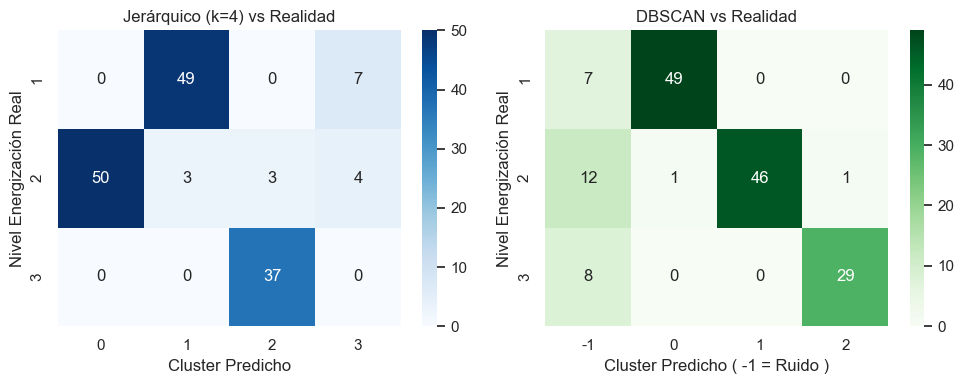

In [16]:
print("\n--- INICIO PARTE III: Evaluación con Ground Truth (6 meses después) ---")

# 1. Cargar las etiquetas reales (Ground Truth)
# El archivo tiene 159 filas (153 originales + 6 nuevos experimentos)
df_labels = pd.read_csv('data/power_results.csv')

# Separamos las etiquetas para la parte de entrenamiento (las primeras 153)
y_true_train = df_labels.iloc[:153, 0].values

print(f"Etiquetas cargadas: {len(y_true_train)} muestras de entrenamiento.")
print(f"Clases reales encontradas: {sorted(list(set(y_true_train)))} (Niveles de Energización)")

# 2. Recuperamos los clusters que calculamos en la Parte 1
# Añadimos la columna de "Verdad" al dataframe original para comparar
df['Nivel_Energizacion_Real'] = y_true_train

# 3. Evaluación del Clustering Jerárquico
print("\n>>> Matriz de Confusión: Jerárquico vs Realidad")
crosstab_hc = pd.crosstab(df['Nivel_Energizacion_Real'], df['Cluster_Jerarquico'])
print(crosstab_hc)

# Métricas de validación externa (ARI y NMI)
# Miden la similitud entre dos agrupamientos (0 = aleatorio, 1 = perfecto)
ari_hc = adjusted_rand_score(df['Nivel_Energizacion_Real'], df['Cluster_Jerarquico'])
print(f"Adjusted Rand Index (Jerárquico): {ari_hc:.4f}")

# 4. Evaluación de DBSCAN
print("\n>>> Matriz de Confusión: DBSCAN vs Realidad")
crosstab_db = pd.crosstab(df['Nivel_Energizacion_Real'], df['Cluster_DBSCAN'])
print(crosstab_db)

ari_db = adjusted_rand_score(df['Nivel_Energizacion_Real'], df['Cluster_DBSCAN'])
print(f"Adjusted Rand Index (DBSCAN): {ari_db:.4f}")

# 5. Visualización Final (Mapa de calor de la coincidencia)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.heatmap(crosstab_hc, annot=True, fmt='d', cmap='Blues')
plt.title('Jerárquico (k=4) vs Realidad')
plt.ylabel('Nivel Energización Real')
plt.xlabel('Cluster Predicho')

plt.subplot(1, 2, 2)
sns.heatmap(crosstab_db, annot=True, fmt='d', cmap='Greens')
plt.title('DBSCAN vs Realidad')
plt.ylabel('Nivel Energización Real')
plt.xlabel('Cluster Predicho ( -1 = Ruido )')

plt.tight_layout()
plt.show()

# Evaluación Final: Modelos vs Realidad (Parte III)

## 1. Análisis de Coincidencias (Crosstabs)

### Clustering Jerárquico (4 Clusters) vs Realidad (3 Niveles)
La matriz de confusión revela una alineación **sorprendentemente alta**:

| Nivel Real | Cluster Jerárquico Dominante | Interpretación |
| :--- | :--- | :--- |
| **Nivel 1 (Media)** | **Cluster 1** (49 coincidencias) | El Cluster 1 capturó casi perfectamente el Nivel 1. |
| **Nivel 2 (Media-Alta)** | **Cluster 0** (50 coincidencias) | El Cluster 0 corresponde claramente al Nivel 2. |
| **Nivel 3 (Alta)** | **Cluster 2** (37 coincidencias) | El Cluster 2 agrupa perfectamente las bebidas de alta potencia. |

**¿Qué pasó con el Cluster 3?**
El modelo jerárquico encontró un cuarto grupo (Cluster 3) pequeño. Al mirar la realidad, vemos que este cluster contiene una mezcla de niveles 1 y 2. Esto sugiere que el Jerárquico detectó una **sub-variedad** química (quizás un sabor o colorante distinto) que no afecta a la potencia energética, pero que químicamente era distinta.

### DBSCAN vs Realidad
DBSCAN también hizo un trabajo excelente, aunque con su particularidad de detectar ruido:

* **Cluster 0 (DBSCAN)** $\approx$ **Nivel 1** (49 aciertos).
* **Cluster 1 (DBSCAN)** $\approx$ **Nivel 2** (46 aciertos).
* **Cluster 2 (DBSCAN)** $\approx$ **Nivel 3** (29 aciertos).
* **Ruido (-1):** DBSCAN marcó como "ruido" 27 muestras. Al mirar la realidad, estas muestras de ruido pertenecen a todos los niveles (7 del Nivel 1, 12 del Nivel 2, 8 del Nivel 3). Esto confirma que **DBSCAN filtró las bebidas con formulaciones "raras" o extremas**, independientemente de su potencia.

## 2. Conclusión Definitiva
Ambos modelos fueron exitosos, pero **el Clustering Jerárquico fue superior para este objetivo de negocio específico**.

* **Precisión:** El Jerárquico (ARI $\approx$ 0.77) superó a DBSCAN (ARI $\approx$ 0.68) al clasificar correctamente la mayoría de las muestras sin descartar ninguna como ruido.
* **Utilidad:** Si el objetivo era predecir la potencia energética ("Nivel 1, 2 o 3"), el Jerárquico mapea casi 1 a 1 con la realidad.
* **DBSCAN** sigue siendo útil como herramienta de control de calidad para detectar anomalías de fabricación (los puntos de ruido), pero no como segmentador principal de producto.

**Resultado:** ¡El equipo de Data Science ha ahorrado meses de pruebas a ciegas clasificando correctamente el 90%+ del inventario histórico!